In [1]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000002AEB4049E50> [0]

In [3]:
REGION = 'Nord'
YEAR = 2025

In [ ]:
# timeline_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_filled_cleaned.csv', encoding=enc)

In [4]:
timeline_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_08_filled_cleaned.csv', encoding=enc)

In [5]:
try:
    timeline_file.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

In [6]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15285.0,14471.0,0.0
1,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-02,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15285.0,14471.0,0.0
2,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-03,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15041.0,14471.0,0.0
3,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-04,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15252.0,14592.0,0.0
4,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-05,2025,1,0.226539,-0.151716,-0.301205,0.151716,0.248447,-0.133282,-0.302334,0.133282,0.019616,0.028816,0.011849,0.028816,15019.0,14479.0,0.0


In [7]:
print(f'Shape of the timeline file: {timeline_file.shape}')

Shape of the timeline file: (962037, 24)


Text(0.5, 1.0, 'Year: 2025')

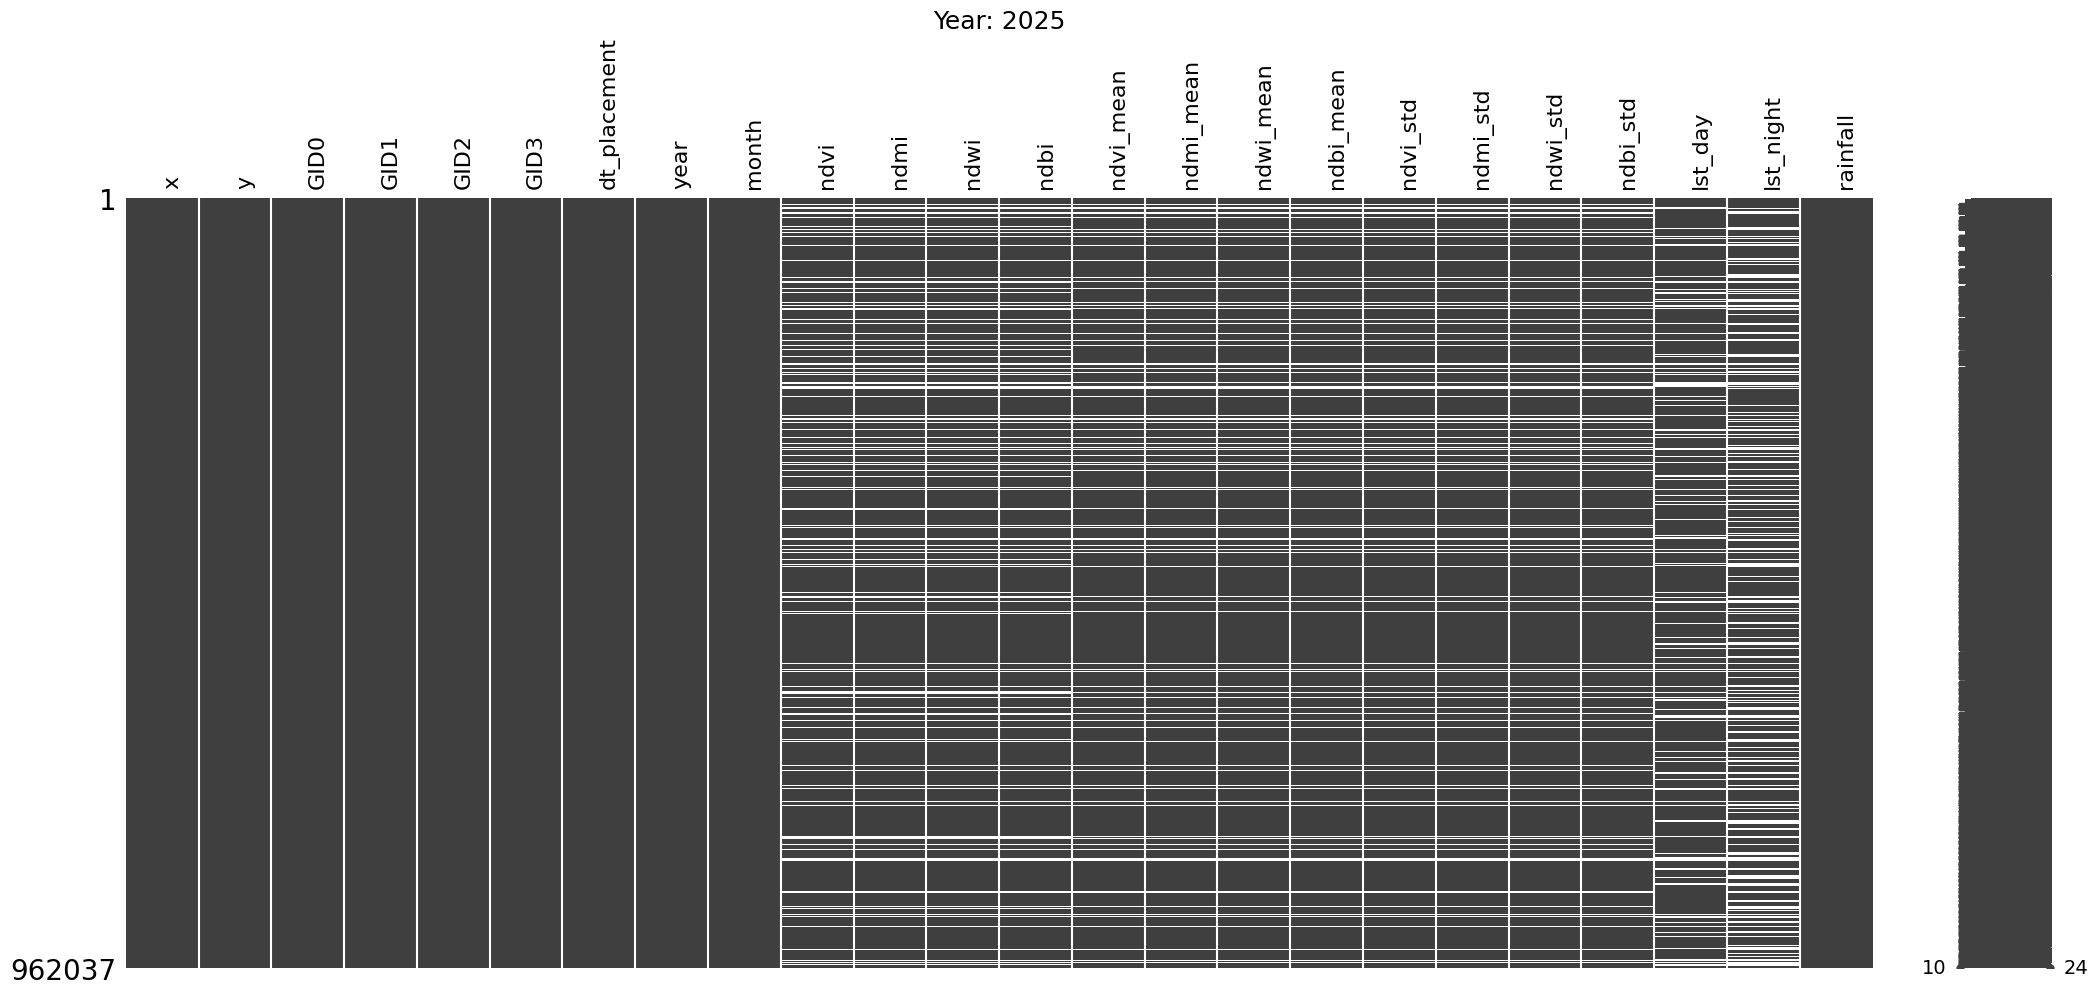

In [8]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2

In [10]:
timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [11]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15285.0,14471.0,0.0,14878.0,0.5,0.866
1,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-02,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15285.0,14471.0,0.0,14878.0,0.5,0.866
2,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-03,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15041.0,14471.0,0.0,14756.0,0.5,0.866
3,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-04,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15252.0,14592.0,0.0,14922.0,0.5,0.866
4,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-05,2025,1,0.226539,-0.151716,-0.301205,0.151716,0.248447,-0.133282,-0.302334,0.133282,0.019616,0.028816,0.011849,0.028816,15019.0,14479.0,0.0,14749.0,0.5,0.866


In [12]:
geomorphological = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Geomorphological.csv', encoding=enc)
geomorphological.columns = geomorphological.columns.str.lower()
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,13.56021,9.29772,15102.128622,680.892978,2,151.604907,185.418439,180.092206,0.0,1.000000
1,13.59642,9.22586,6838.003488,1865.794331,1,201.794101,197.674022,183.049512,0.0,2.249840
2,13.59642,9.26179,9504.069954,2074.586084,1,136.247919,186.061883,180.318899,0.0,9.050964
3,13.59642,9.29772,12864.041385,781.399397,1,143.777456,188.894941,180.250312,0.0,2.000000
4,13.63262,9.18992,1899.383898,1344.931378,1,151.874866,187.347864,179.798661,0.0,1.000000


In [13]:
geomorphological['x_rounded'] = geomorphological['x'].round(4)
geomorphological['y_rounded'] = geomorphological['y'].round(4)

geomorphological.drop(columns=['x', 'y'], inplace=True)

timeline_file['x_rounded'] = timeline_file['x'].round(4)
timeline_file['y_rounded'] = timeline_file['y'].round(4)

timeline_file = pd.merge(timeline_file, geomorphological, on=['x_rounded', 'y_rounded'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15285.0,14471.0,0.0,14878.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
1,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-02,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15285.0,14471.0,0.0,14878.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
2,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-03,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15041.0,14471.0,0.0,14756.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
3,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-04,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15252.0,14592.0,0.0,14922.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735
4,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-05,2025,1,0.226539,-0.151716,-0.301205,0.151716,0.248447,-0.133282,-0.302334,0.133282,0.019616,0.028816,0.011849,0.028816,15019.0,14479.0,0.0,14749.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735


Text(0.5, 1.0, 'Year: 2025')

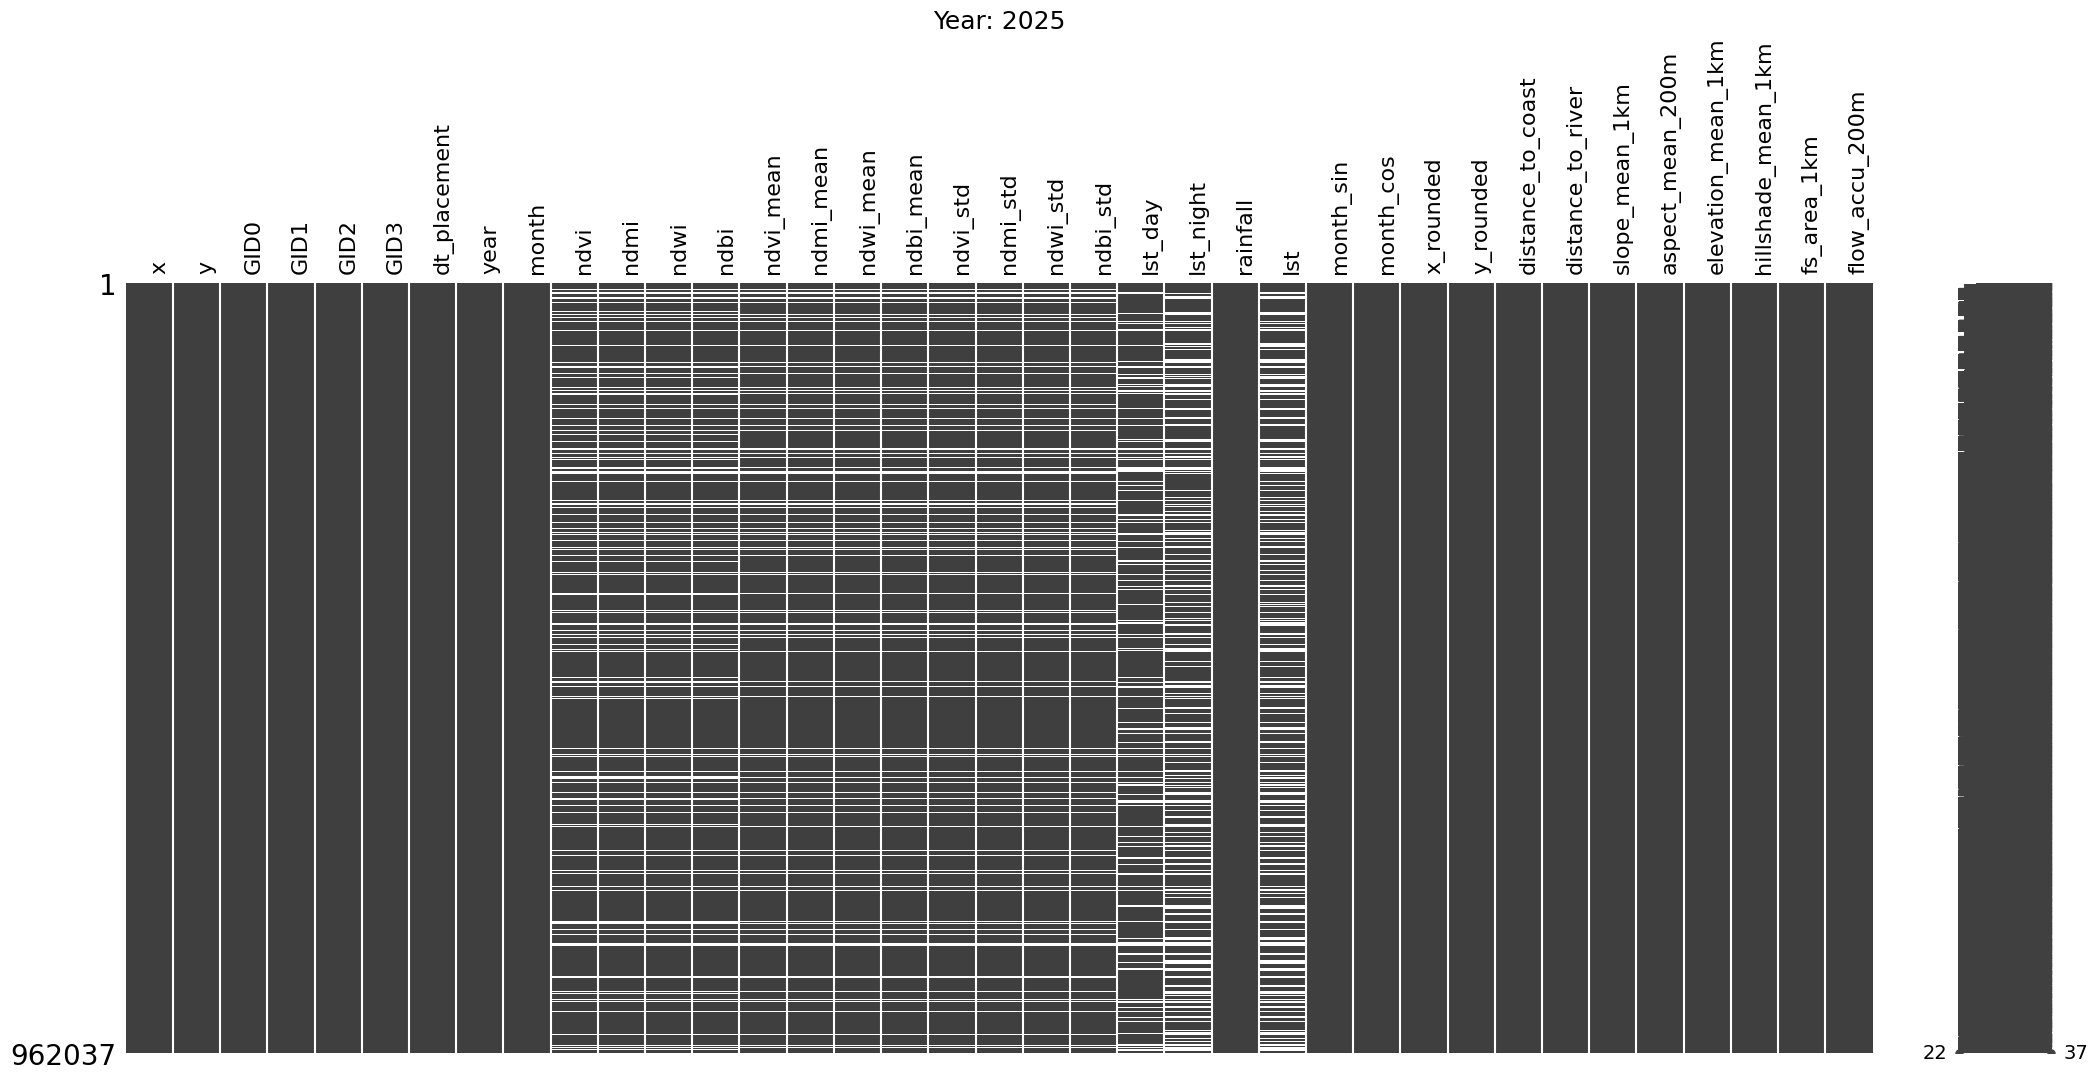

In [14]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [15]:
landcover = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Landcover_2001-2024_processed.csv')
landcover = landcover[landcover['year'] == YEAR - 1].copy()
landcover.head()

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
91057,13.56021,9.29772,2024,31,99,36,98.0,30,99,12,12,1,6,7,2,0
91058,13.59642,9.22586,2024,31,99,36,99.0,30,99,12,12,3,5,8,2,0
91059,13.59642,9.26179,2024,31,98,36,97.0,30,98,12,12,1,6,7,2,0
91060,13.59642,9.29772,2024,31,98,36,97.0,30,98,12,12,1,6,7,2,0
91061,13.63262,9.18992,2024,31,99,36,99.0,30,99,12,12,1,6,7,2,0


In [16]:
landcover['x_rounded'] = landcover['x'].round(4)
landcover['y_rounded'] = landcover['y'].round(4)
landcover.rename(columns={'year': 'year_lc'}, inplace=True)
landcover.drop(columns=['x', 'y'], inplace=True)

timeline_file['year_lc'] = timeline_file['year'] - 1

In [17]:
timeline_file = pd.merge(timeline_file, landcover, on=['x_rounded', 'y_rounded', 'year_lc'], how='left')

timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,x_rounded,y_rounded,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15285.0,14471.0,0.0,14878.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2024,31,99,36,96.0,30,99,12,12,1,6,7,2,0
1,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-02,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15285.0,14471.0,0.0,14878.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2024,31,99,36,96.0,30,99,12,12,1,6,7,2,0
2,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-03,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15041.0,14471.0,0.0,14756.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2024,31,99,36,96.0,30,99,12,12,1,6,7,2,0
3,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-04,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15252.0,14592.0,0.0,14922.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2024,31,99,36,96.0,30,99,12,12,1,6,7,2,0
4,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-05,2025,1,0.226539,-0.151716,-0.301205,0.151716,0.248447,-0.133282,-0.302334,0.133282,0.019616,0.028816,0.011849,0.028816,15019.0,14479.0,0.0,14749.0,0.5,0.866,12.2931,8.2197,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2024,31,99,36,96.0,30,99,12,12,1,6,7,2,0


In [18]:
timeline_file.loc[timeline_file['lc_prop1_assessment'] < 80, 'lc_prop1'] = np.nan
timeline_file.loc[timeline_file['lc_prop2_assessment'] < 80, 'lc_prop2'] = np.nan
timeline_file.loc[timeline_file['lc_prop3_assessment'] < 80, 'lc_prop3'] = np.nan

In [19]:
timeline_file.drop(columns=['x_rounded', 'y_rounded', 'lc_prop1_assessment', 'lc_prop2_assessment', 'lc_prop3_assessment', 'lw', 'qc'], inplace=True)

Text(0.5, 1.0, 'Year: 2025')

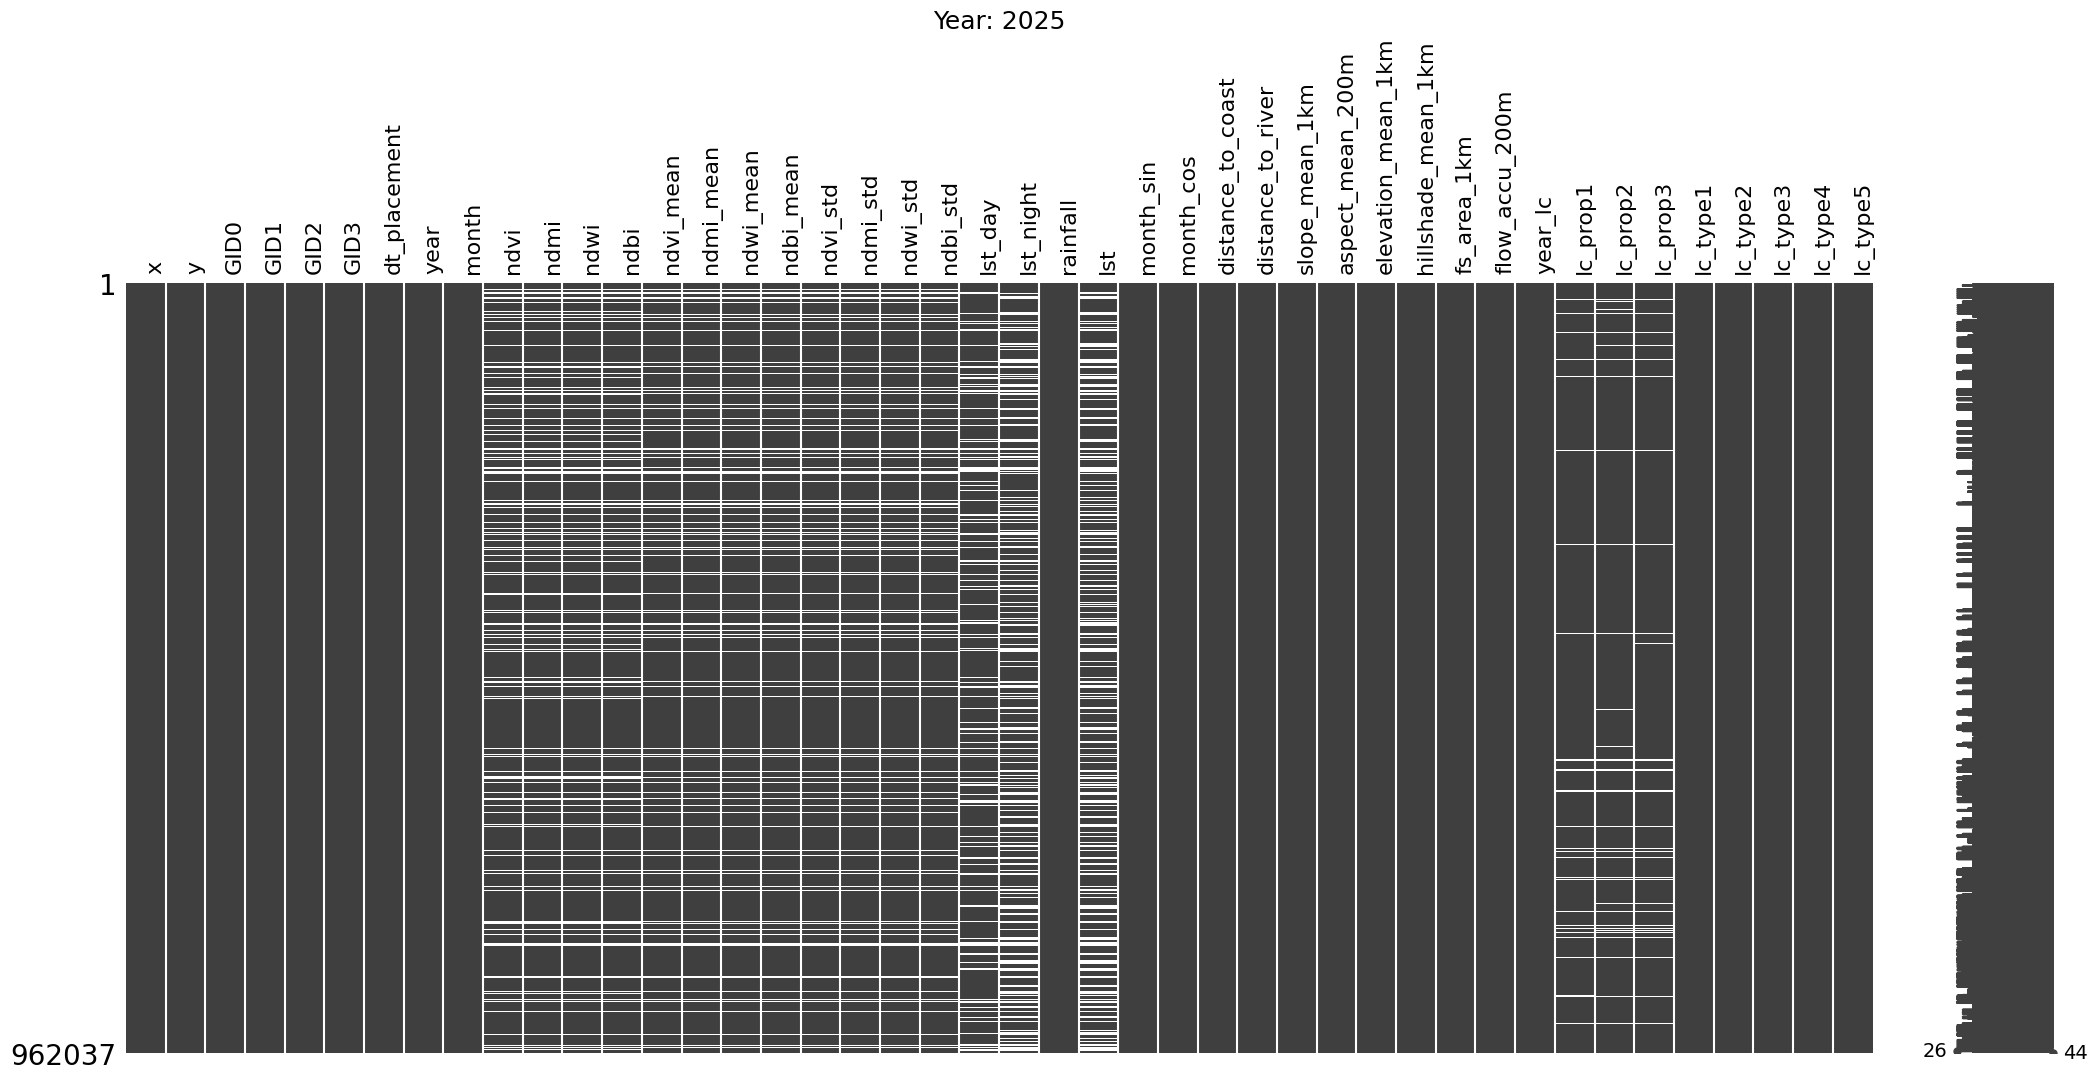

In [20]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [21]:
timeline_file

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-01,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15285.0,14471.0,0.00,14878.0,0.500,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2024,31.0,36.0,30.0,12,12,1,6,7
1,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-02,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15285.0,14471.0,0.00,14878.0,0.500,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2024,31.0,36.0,30.0,12,12,1,6,7
2,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-03,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15041.0,14471.0,0.00,14756.0,0.500,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2024,31.0,36.0,30.0,12,12,1,6,7
3,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-04,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15252.0,14592.0,0.00,14922.0,0.500,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2024,31.0,36.0,30.0,12,12,1,6,7
4,12.29306,8.21972,nord,faro,poli,balkossa,2025-01-05,2025,1,0.226539,-0.151716,-0.301205,0.151716,0.248447,-0.133282,-0.302334,0.133282,0.019616,0.028816,0.011849,0.028816,15019.0,14479.0,0.00,14749.0,0.500,0.866,112418.65451,535.046617,4,148.643491,351.010816,178.001355,0.0,1.714735,2024,31.0,36.0,30.0,12,12,1,6,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
962032,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2025-08-27,2025,8,0.552059,0.266278,-0.436590,-0.266278,0.527417,0.227485,-0.418930,-0.227485,0.064754,0.039699,0.049656,0.039699,NaN,NaN,0.00,NaN,-0.866,-0.500,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,2024,22.0,20.0,20.0,9,9,4,4,4
962033,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2025-08-28,2025,8,0.552059,0.266278,-0.436590,-0.266278,0.527417,0.227485,-0.418930,-0.227485,0.064754,0.039699,0.049656,0.039699,NaN,NaN,0.00,NaN,-0.866,-0.500,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,2024,22.0,20.0,20.0,9,9,4,4,4
962034,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2025-08-29,2025,8,0.552059,0.266278,-0.436590,-0.266278,0.527417,0.227485,-0.418930,-0.227485,0.064754,0.039699,0.049656,0.039699,NaN,NaN,0.00,NaN,-0.866,-0.500,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,2024,22.0,20.0,20.0,9,9,4,4,4
962035,15.55146,7.75259,nord,mayo-rey,touboro,mafare,2025-08-30,2025,8,0.552059,0.266278,-0.436590,-0.266278,0.527417,0.227485,-0.418930,-0.227485,0.064754,0.039699,0.049656,0.039699,NaN,NaN,4.66,NaN,-0.866,-0.500,75745.37949,68.862894,3,177.353198,461.652670,179.568663,0.0,3163.658249,2024,22.0,20.0,20.0,9,9,4,4,4


In [22]:
gid_unit_counts = []

for gid_unit in timeline_file.GID3.sort_values().unique().tolist():
    count = (timeline_file['GID3'] == gid_unit).sum()
    gid_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_unit_counts_df = pd.DataFrame(gid_unit_counts)

In [23]:
fig = px.bar(gid_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [24]:
group_cols = ['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3']
mode_cols = ['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5']
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']

grouped_by_gid3 = timeline_file.groupby(group_cols, as_index = False)

grouped_by_gid3_mean = grouped_by_gid3.mean()
grouped_by_gid3_std = grouped_by_gid3.std()

grouped_by_gid3_most_common = timeline_file[group_cols].drop_duplicates()

for col in mode_cols:
    mode_series = (timeline_file.groupby(group_cols)[col].value_counts().groupby(level=group_cols).idxmax().apply(lambda x: x[-1]).reset_index(name=col))
    grouped_by_gid3_most_common = grouped_by_gid3_most_common.merge(mode_series, on=group_cols, how='left')


In [25]:
grouped_by_gid3_mean.drop(columns = mode_cols, inplace=True)
grouped_by_gid3_std = grouped_by_gid3_std[group_cols + geo_cols].copy()
grouped_by_gid3_std.columns = group_cols + [f"{col}_std" for col in geo_cols]

In [26]:
grouped_by_gid3 = grouped_by_gid3_mean.merge(grouped_by_gid3_std, on=group_cols, how='left')
grouped_by_gid3 = grouped_by_gid3.merge(grouped_by_gid3_most_common, on=group_cols, how='left')

In [27]:
print(f'Shape of the grouped_by_gid3 file: {grouped_by_gid3.shape}')

Shape of the grouped_by_gid3 file: (35235, 52)


Text(0.5, 1.0, 'Year: 2025.0')

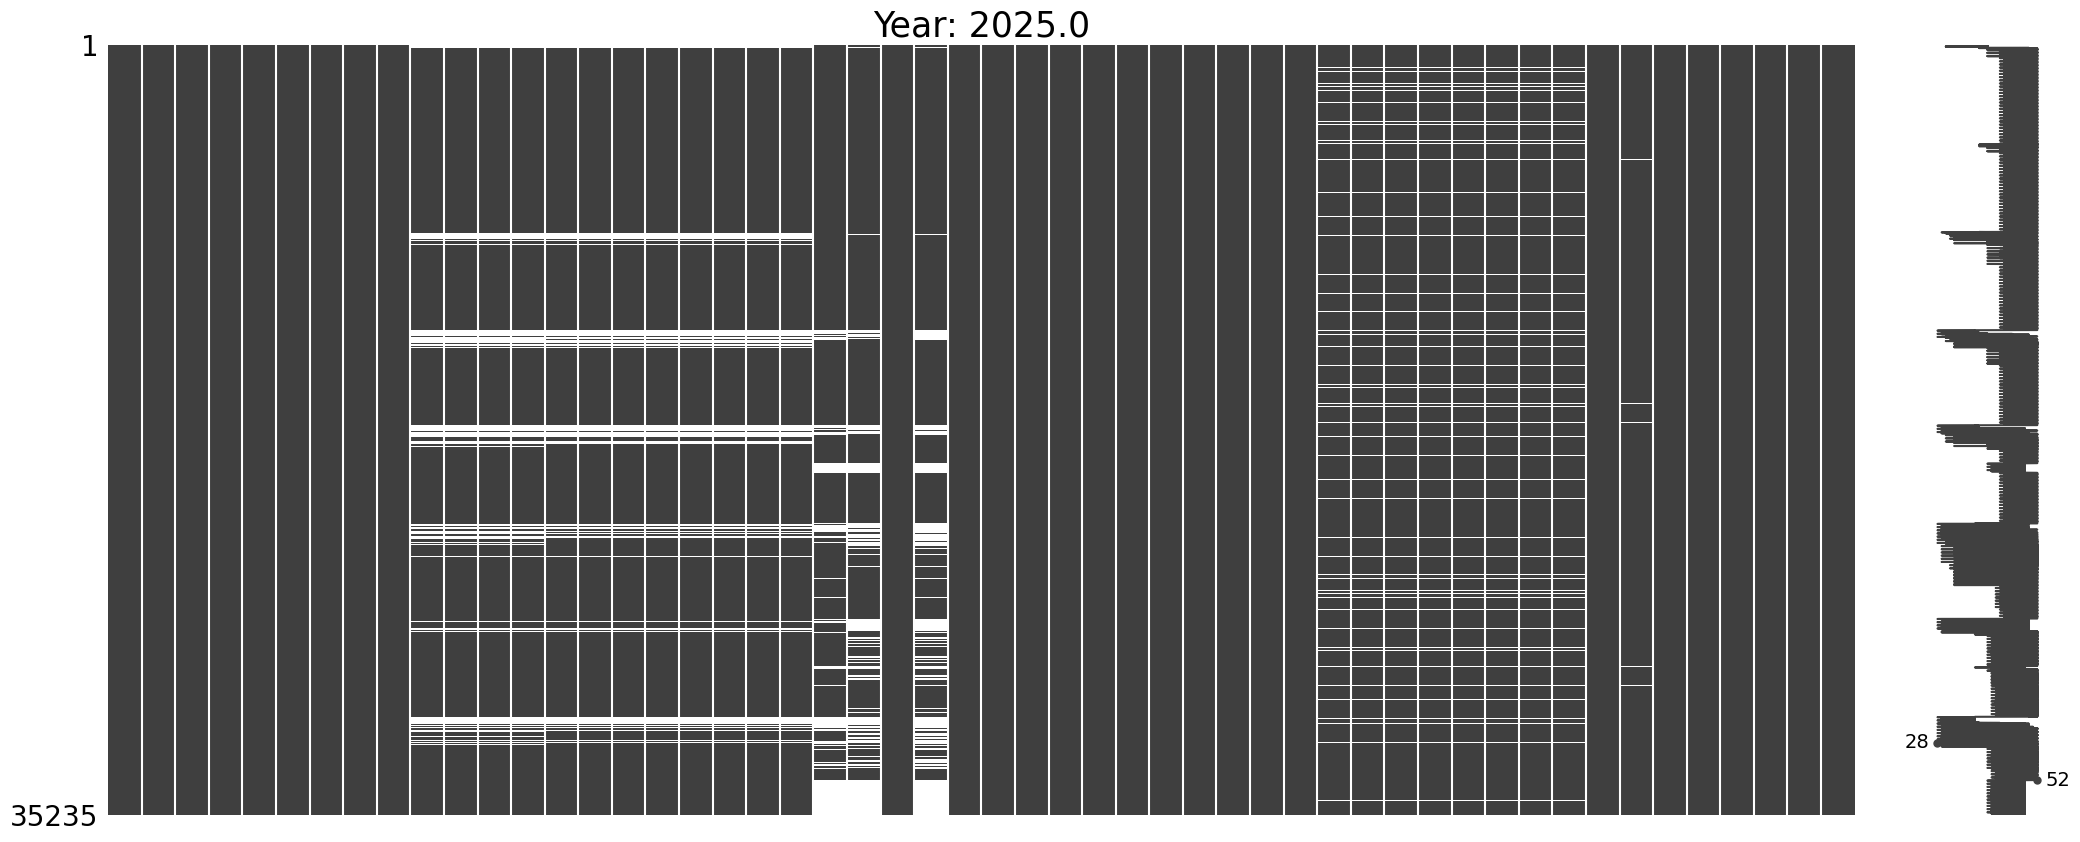

In [28]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=25)

In [29]:
gid_mean_unit_counts = []

for gid_unit in grouped_by_gid3.GID3.sort_values().unique().tolist():
    count = (grouped_by_gid3['GID3'] == gid_unit).sum()
    gid_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_mean_unit_counts_df = pd.DataFrame(gid_mean_unit_counts)

In [30]:
fig = px.bar(gid_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [31]:
grouped_by_gid3 = convert_temperature(grouped_by_gid3)

In [32]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2025-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2025.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.798000,NaN,0.0,NaN,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2024.0,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8
1,2025-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2025.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.571026,NaN,0.0,NaN,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2024.0,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8
2,2025-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2025.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.383333,NaN,0.0,NaN,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2024.0,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8
3,2025-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2025.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.553636,16.75,0.0,26.151818,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2024.0,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,3,5,8
4,2025-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2025.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.816667,NaN,0.0,NaN,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2024.0,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8


In [33]:
grouped_by_gid3['year'] = grouped_by_gid3['year'].astype(int)
grouped_by_gid3['year_lc'] = grouped_by_gid3['year_lc'].astype(int)
grouped_by_gid3['month'] = grouped_by_gid3['month'].astype(int)

In [34]:
grouped_by_gid3.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5
0,2025-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.798000,NaN,0.0,NaN,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2024,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8
1,2025-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.571026,NaN,0.0,NaN,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2024,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8
2,2025-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.383333,NaN,0.0,NaN,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2024,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8
3,2025-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.553636,16.75,0.0,26.151818,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2024,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,3,5,8
4,2025-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.816667,NaN,0.0,NaN,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2024,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8


Text(0.5, 1.0, 'Year: 2025')

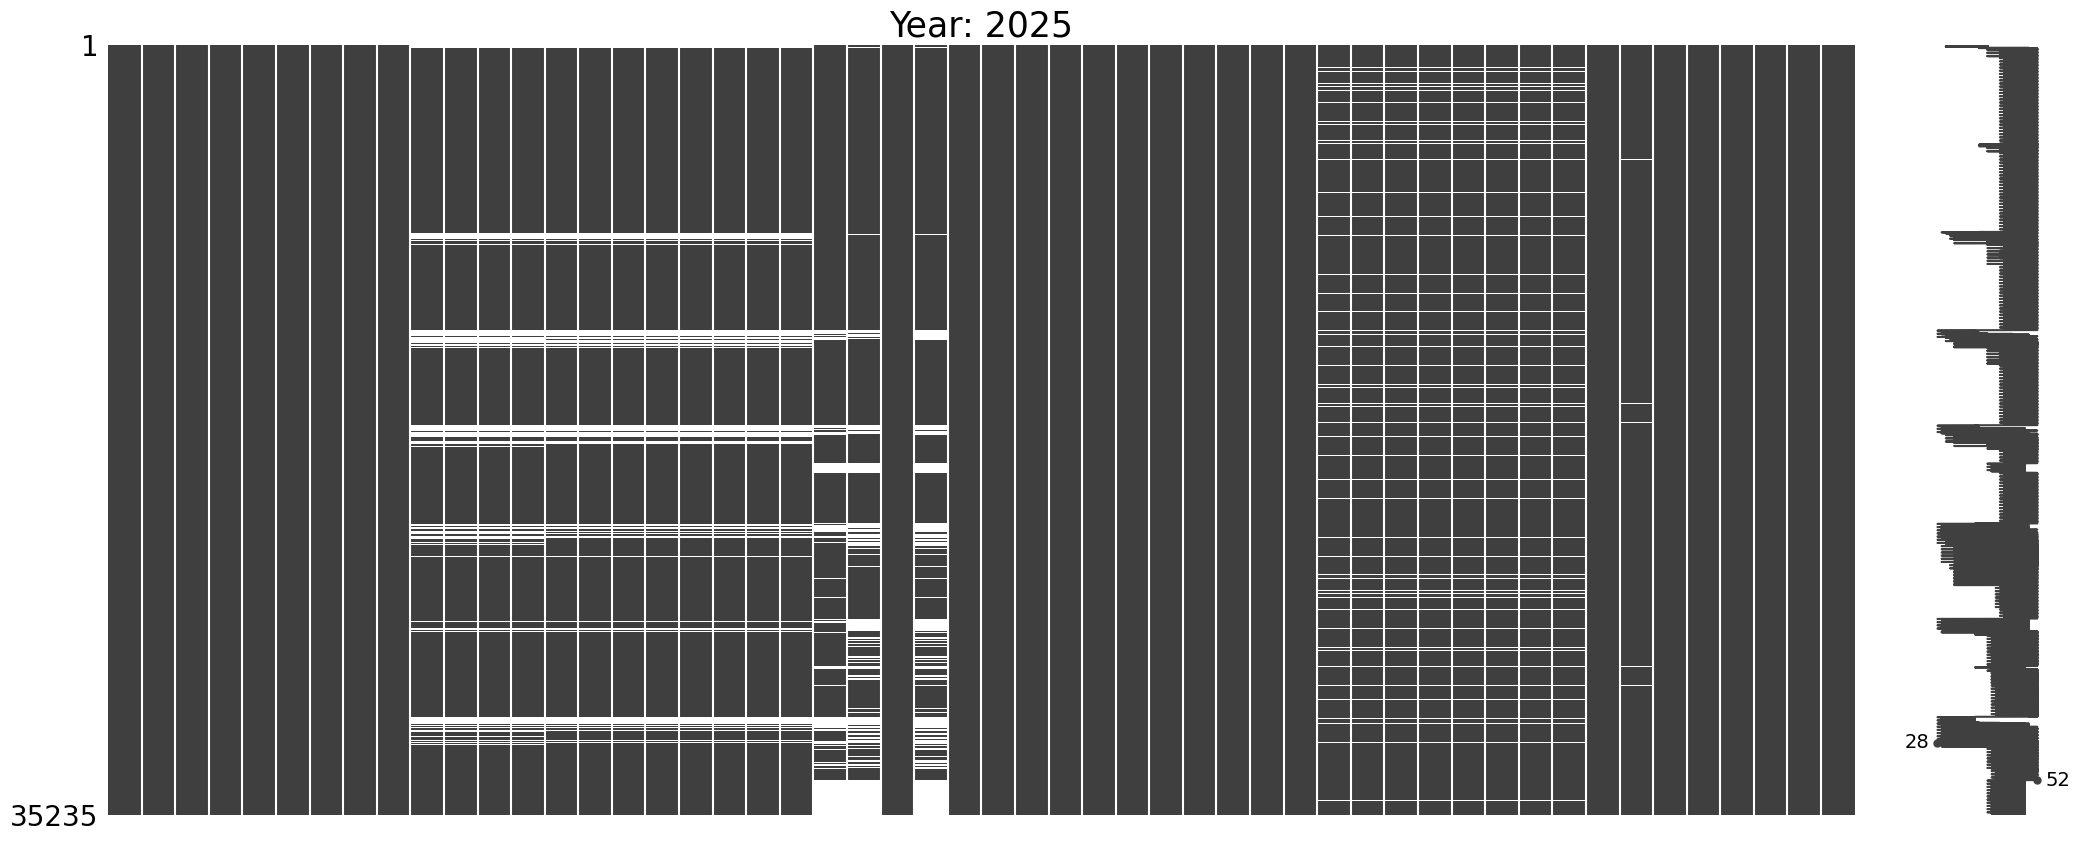

In [35]:
msno.matrix(grouped_by_gid3, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3.year.iloc[0]}", fontsize=25)

In [36]:
# Group by the needed dimensions
grouped_mask = grouped_by_gid3.groupby(['GID2', 'GID3', 'year', 'month'])

# Compute the min and max temperature across lst_day and lst_night
monthly_lst_min = grouped_mask[['lst_day', 'lst_night']].min().min(axis=1)
monthly_lst_max = grouped_mask[['lst_day', 'lst_night']].max().max(axis=1)

# Compute total precipitation
monthly_rainfall_acc = grouped_mask['rainfall'].sum()

# Combine results into a single DataFrame
min_max_acc_weather_df = pd.DataFrame({
    'monthly_lst_min': monthly_lst_min,
    'monthly_lst_max': monthly_lst_max,
    'monthly_rainfall_acc': monthly_rainfall_acc
}).reset_index()

In [37]:
min_max_acc_weather_df

,GID2,GID3,year,month,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,bibemi,adoumri,2025,1,15.514000,37.874000,0.596000
1,bibemi,adoumri,2025,2,17.618000,41.554000,6.442000
2,bibemi,adoumri,2025,3,21.062000,48.010000,7.892000
3,bibemi,adoumri,2025,4,20.986000,45.218000,30.993999
4,bibemi,adoumri,2025,5,18.896667,39.394000,13.592000
...,...,...,...,...,...,...,...
1155,touboro,yanli,2025,4,19.523333,44.708710,69.773869
1156,touboro,yanli,2025,5,21.646774,38.155161,48.248709
1157,touboro,yanli,2025,6,23.548065,34.761034,267.948705
1158,touboro,yanli,2025,7,26.746000,28.300000,267.903865


In [38]:
dataset = pd.merge(grouped_by_gid3, min_max_acc_weather_df, on=['GID2', 'GID3', 'year', 'month'], how='left')

In [39]:
dataset.head()


,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2025-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.798000,NaN,0.0,NaN,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2024,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8,15.514000,37.874000,0.596000
1,2025-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.571026,NaN,0.0,NaN,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2024,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8,16.601795,37.660769,0.942564
2,2025-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.383333,NaN,0.0,NaN,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2024,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8,16.912667,37.439333,0.440000
3,2025-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.553636,16.75,0.0,26.151818,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2024,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,3,5,8,15.577273,36.582727,0.068182
4,2025-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.816667,NaN,0.0,NaN,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2024,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8,18.743333,38.456667,0.000000


Text(0.5, 1.0, 'Year: 2025')

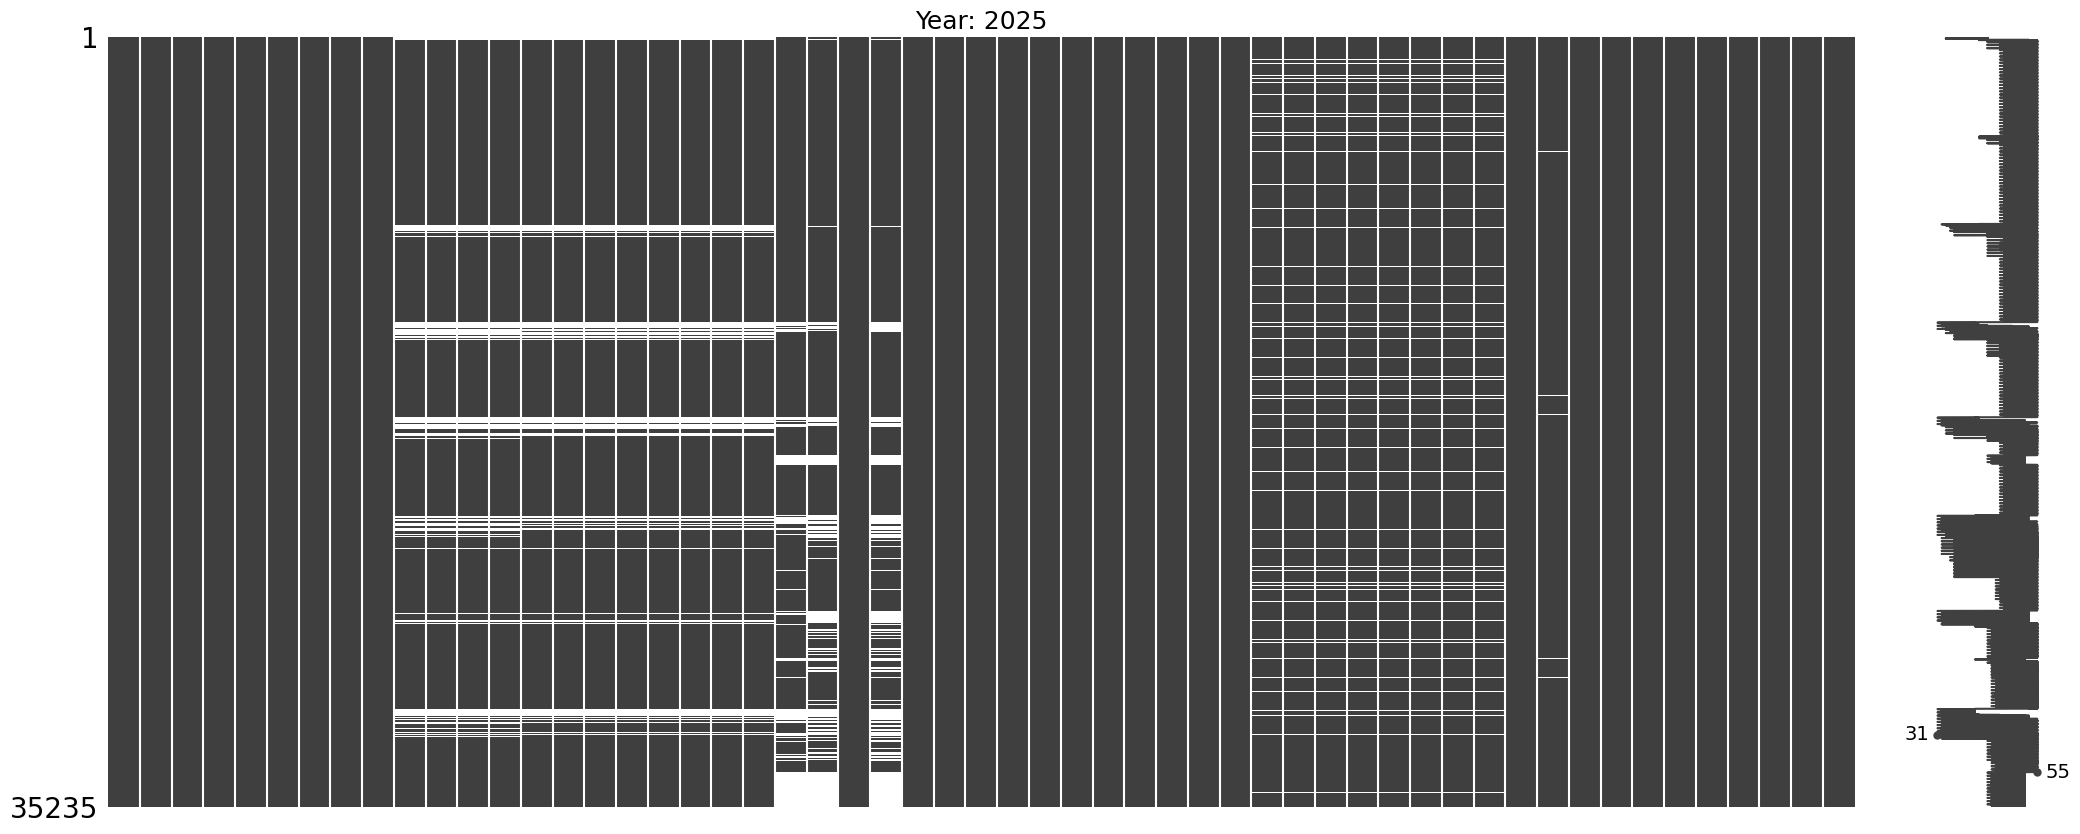

In [40]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [41]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [42]:
dataset.head()

,dt_placement_daily,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,dt_placement
0,2025-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.798000,NaN,0.0,NaN,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2024,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12,12,3,5,8,15.514000,37.874000,0.596000,2025-01
1,2025-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.571026,NaN,0.0,NaN,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2024,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12,12,3,5,8,16.601795,37.660769,0.942564,2025-01
2,2025-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.383333,NaN,0.0,NaN,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2024,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12,12,3,5,8,16.912667,37.439333,0.440000,2025-01
3,2025-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.553636,16.75,0.0,26.151818,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2024,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12,12,3,5,8,15.577273,36.582727,0.068182,2025-01
4,2025-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.816667,NaN,0.0,NaN,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2024,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12,12,3,5,8,18.743333,38.456667,0.000000,2025-01


In [43]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement','GID0','GID1','GID2','GID3'], as_index = False)

In [44]:
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_sum = grouped_by_month.sum()

In [45]:
grouped_by_month_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2025-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2025.0,1.0,0.221611,-0.115693,-0.351430,0.115693,0.222415,-0.121217,-0.359687,0.121217,0.014312,0.018195,0.016413,0.018195,33.593226,18.475655,0.019226,25.923931,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2024.0,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.514000,37.874000,0.596000
1,2025-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2025.0,1.0,0.228015,-0.128318,-0.343611,0.128318,0.225038,-0.131594,-0.342374,0.131594,0.018079,0.017870,0.020000,0.017870,33.475393,19.666408,0.030405,26.519307,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2024.0,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.601795,37.660769,0.942564
2,2025-01,nord,benoue,bibemi,bide,13.972945,9.422292,2025.0,1.0,0.228220,-0.101896,-0.347788,0.101896,0.231374,-0.096971,-0.352921,0.096971,0.015842,0.016957,0.016130,0.016957,33.477699,19.521544,0.014194,26.467861,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2024.0,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.912667,37.439333,0.440000
3,2025-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2025.0,1.0,0.248493,-0.103664,-0.337475,0.103664,0.249743,-0.108167,-0.342317,0.108167,0.020745,0.028386,0.021056,0.028386,32.457507,18.103358,0.002199,25.280433,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2024.0,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.577273,36.582727,0.068182
4,2025-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2025.0,1.0,0.215481,-0.051379,-0.305649,0.051379,0.217226,-0.045809,-0.312697,0.045809,0.023719,0.023485,0.028914,0.023485,32.857527,21.004111,0.000000,26.898167,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2024.0,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,18.743333,38.456667,0.000000


In [46]:
print(f'Shape of the grouped_by_month_mean file: {grouped_by_month_mean.shape}')

Shape of the grouped_by_month_mean file: (1160, 55)


Text(0.5, 1.0, 'Year: 2025.0')

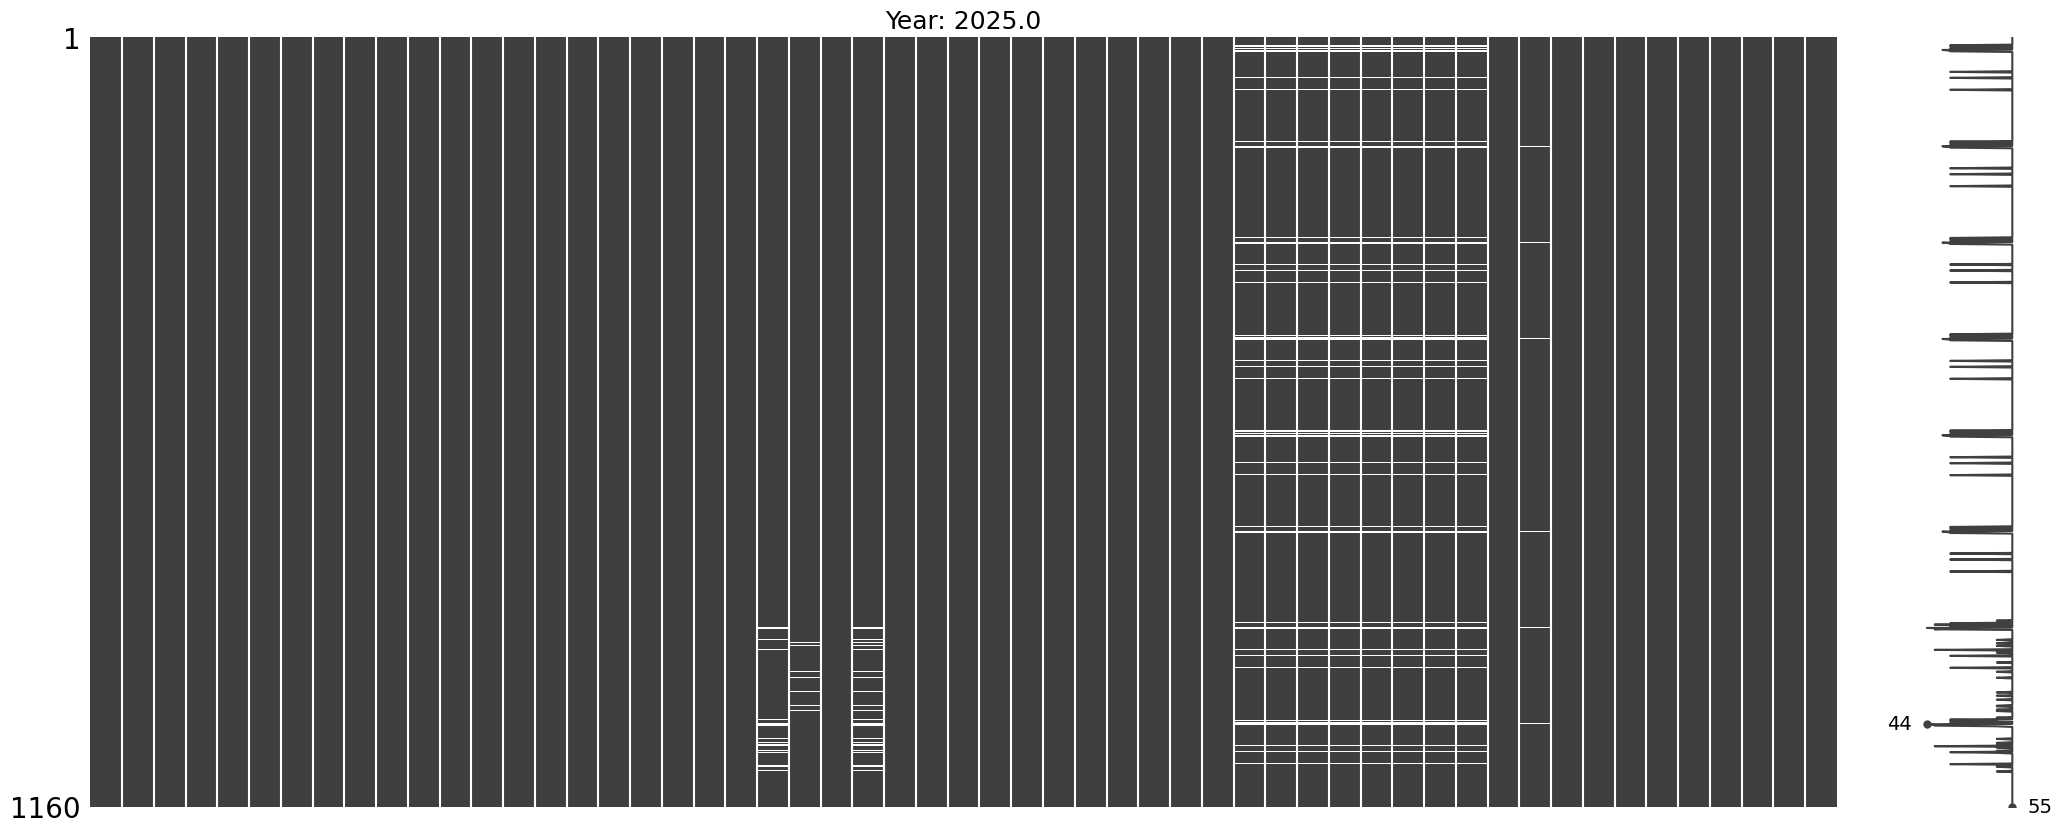

In [47]:
msno.matrix(grouped_by_month_mean, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_month_mean.year.iloc[0]}", fontsize=18)

In [48]:
month_mean_unit_counts = []

for gid_unit in grouped_by_month_mean.GID3.sort_values().unique().tolist():
    count = (grouped_by_month_mean['GID3'] == gid_unit).sum()
    month_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

month_mean_unit_counts_df = pd.DataFrame(month_mean_unit_counts)

In [49]:
fig = px.bar(month_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [50]:
grouped_by_month_mean['year'] = grouped_by_month_mean['year'].astype(int)
grouped_by_month_mean['year_lc'] = grouped_by_month_mean['year_lc'].astype(int)
grouped_by_month_mean['month'] = grouped_by_month_mean['month'].astype(int)

In [51]:
grouped_by_month_mean

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2025-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2025,1,0.221611,-0.115693,-0.351430,0.115693,0.222415,-0.121217,-0.359687,0.121217,0.014312,0.018195,0.016413,0.018195,33.593226,18.475655,0.019226,25.923931,0.500,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2024,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.514000,37.874000,0.596000
1,2025-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2025,1,0.228015,-0.128318,-0.343611,0.128318,0.225038,-0.131594,-0.342374,0.131594,0.018079,0.017870,0.020000,0.017870,33.475393,19.666408,0.030405,26.519307,0.500,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2024,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.601795,37.660769,0.942564
2,2025-01,nord,benoue,bibemi,bide,13.972945,9.422292,2025,1,0.228220,-0.101896,-0.347788,0.101896,0.231374,-0.096971,-0.352921,0.096971,0.015842,0.016957,0.016130,0.016957,33.477699,19.521544,0.014194,26.467861,0.500,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2024,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.912667,37.439333,0.440000
3,2025-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2025,1,0.248493,-0.103664,-0.337475,0.103664,0.249743,-0.108167,-0.342317,0.108167,0.020745,0.028386,0.021056,0.028386,32.457507,18.103358,0.002199,25.280433,0.500,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2024,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.577273,36.582727,0.068182
4,2025-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2025,1,0.215481,-0.051379,-0.305649,0.051379,0.217226,-0.045809,-0.312697,0.045809,0.023719,0.023485,0.028914,0.023485,32.857527,21.004111,0.000000,26.898167,0.500,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2024,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,18.743333,38.456667,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1155,2025-08,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2025,8,0.584817,0.269254,-0.293034,-0.269254,0.569654,0.265639,-0.290047,-0.265639,0.059816,0.039034,0.044323,0.039034,25.276458,16.157089,15.989740,20.743453,-0.866,-0.500,125988.493830,1351.464075,5.487179,165.595614,710.625604,180.155729,0.0,416.446254,2024,9674.688211,975.207537,6.237561,51.830772,161.275638,6.209749,0.0,3164.666798,22.0,20.0,20.0,9.0,9.0,4.0,4.0,4.0,15.250000,26.148542,495.681955
1156,2025-08,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,2025,8,0.611910,0.249040,-0.357736,-0.249040,0.536293,0.259253,-0.338325,-0.259253,0.040306,0.033361,0.031134,0.033361,25.989472,21.545862,15.289199,23.237241,-0.866,-0.500,96382.615442,1575.283286,5.603448,162.531613,676.741170,177.469545,0.0,10.120173,2024,9407.825255,1053.074968,5.902541,47.841931,166.460795,6.074794,0.0,32.532102,22.0,20.0,20.0,9.0,9.0,4.0,4

In [52]:
grouped_by_month_sum = grouped_by_month_sum[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'rainfall']].copy()
grouped_by_month_sum.rename(columns={"rainfall": "rainfall_acc"}, inplace=True)

dataset = pd.merge(grouped_by_month_mean, grouped_by_month_sum, on=['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [53]:
dataset.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc
0,2025-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2025,1,0.221611,-0.115693,-0.351430,0.115693,0.222415,-0.121217,-0.359687,0.121217,0.014312,0.018195,0.016413,0.018195,33.593226,18.475655,0.019226,25.923931,0.5,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2024,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.514000,37.874000,0.596000,0.596000
1,2025-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2025,1,0.228015,-0.128318,-0.343611,0.128318,0.225038,-0.131594,-0.342374,0.131594,0.018079,0.017870,0.020000,0.017870,33.475393,19.666408,0.030405,26.519307,0.5,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2024,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.601795,37.660769,0.942564,0.942564
2,2025-01,nord,benoue,bibemi,bide,13.972945,9.422292,2025,1,0.228220,-0.101896,-0.347788,0.101896,0.231374,-0.096971,-0.352921,0.096971,0.015842,0.016957,0.016130,0.016957,33.477699,19.521544,0.014194,26.467861,0.5,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2024,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.912667,37.439333,0.440000,0.440000
3,2025-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2025,1,0.248493,-0.103664,-0.337475,0.103664,0.249743,-0.108167,-0.342317,0.108167,0.020745,0.028386,0.021056,0.028386,32.457507,18.103358,0.002199,25.280433,0.5,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2024,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.577273,36.582727,0.068182,0.068182
4,2025-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2025,1,0.215481,-0.051379,-0.305649,0.051379,0.217226,-0.045809,-0.312697,0.045809,0.023719,0.023485,0.028914,0.023485,32.857527,21.004111,0.000000,26.898167,0.5,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2024,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,18.743333,38.456667,0.000000,0.000000


In [54]:
dataset['location'] = list(zip(dataset['GID2'], dataset['GID3']))
grouped = dataset.groupby(['year', 'location'])
bio_var_names = [f'bio{i}' for i in range(1, 20)]

# Store results
biovars = []

# Iterate over groups
for (year, location), group in grouped:
    tmin = robjects.IntVector(group['monthly_lst_min'].tolist())
    tmax = robjects.IntVector(group['monthly_lst_max'].tolist())
    prec = robjects.IntVector(group['monthly_rainfall_acc'].tolist())

    # Call the R function
    bio_values = list(dismo.biovars(prec, tmin, tmax))

    # Construct the result dict dynamically
    result = {
        'year': year,
        'location': location,
        **dict(zip(bio_var_names, bio_values))
    }
    biovars.append(result)

# Convert to DataFrame
biovars_df = pd.DataFrame(biovars)

In [55]:
dataset = pd.merge(dataset, biovars_df,  how='left', on=['location', 'year'])

dataset.drop(columns=['location'], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [56]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2025-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2025,1,0.221611,-0.115693,-0.351430,0.115693,0.222415,-0.121217,-0.359687,0.121217,0.014312,0.018195,0.016413,0.018195,33.593226,18.475655,0.019226,25.923931,0.500,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2024,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.514000,37.874000,0.596000,0.596000,29.1875,19.125,57.954545,304.651440,48.0,15.0,33.0,27.666667,29.833333,32.000000,26.833333,563.0,193.0,0.0,116.521944,507.0,13.0,43.0,199.0
1,2025-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2025,1,0.228015,-0.128318,-0.343611,0.128318,0.225038,-0.131594,-0.342374,0.131594,0.018079,0.017870,0.020000,0.017870,33.475393,19.666408,0.030405,26.519307,0.500,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2024,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.601795,37.660769,0.942564,0.942564,29.8125,18.375,55.681818,322.863859,49.0,16.0,33.0,27.666667,30.500000,33.166667,27.000000,593.0,210.0,0.0,123.588908,553.0,13.0,34.0,360.0
2,2025-01,nord,benoue,bibemi,bide,13.972945,9.422292,2025,1,0.228220,-0.101896,-0.347788,0.101896,0.231374,-0.096971,-0.352921,0.096971,0.015842,0.016957,0.016130,0.016957,33.477699,19.521544,0.014194,26.467861,0.500,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2024,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.912667,37.439333,0.440000,0.440000,30.0000,19.500,55.714286,401.781746,51.0,16.0,35.0,27.166667,30.500000,34.166667,26.666667,521.0,169.0,0.0,119.224151,478.0,4.0,42.0,164.0
3,2025-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2025,1,0.248493,-0.103664,-0.337475,0.103664,0.249743,-0.108167,-0.342317,0.108167,0.020745,0.028386,0.021056,0.028386,32.457507,18.103358,0.002199,25.280433,0.500,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2024,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.577273,36.582727,0.068182,0.068182,28.6875,18.125,58.467742,287.771611,46.0,15.0,31.0,27.500000,28.833333,31.333333,26.166667,551.0,203.0,0.0,119.238212,501.0,15.0,45.0,208.0
4,2025-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2025,1,0.215481,-0.051379,-0.305649,0.051379,0.217226,-0.045809,-0.312697,0.045809,0.023719,0.023485,0.028914,0.023485,32.857527,21.004111,0.000000,26.898167,0.500,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2024,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,18.743333,38.456667,0.000000,0.000000,30.6250,18.000,62.068966,274.837614,47.0,18.0,29.0,28.833333,30.333333,33.666667,28.166667,595.0,199.0,0.0,120.248526,546.0,3.0,48.0,200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

Text(0.5, 1.0, 'Year: 2025')

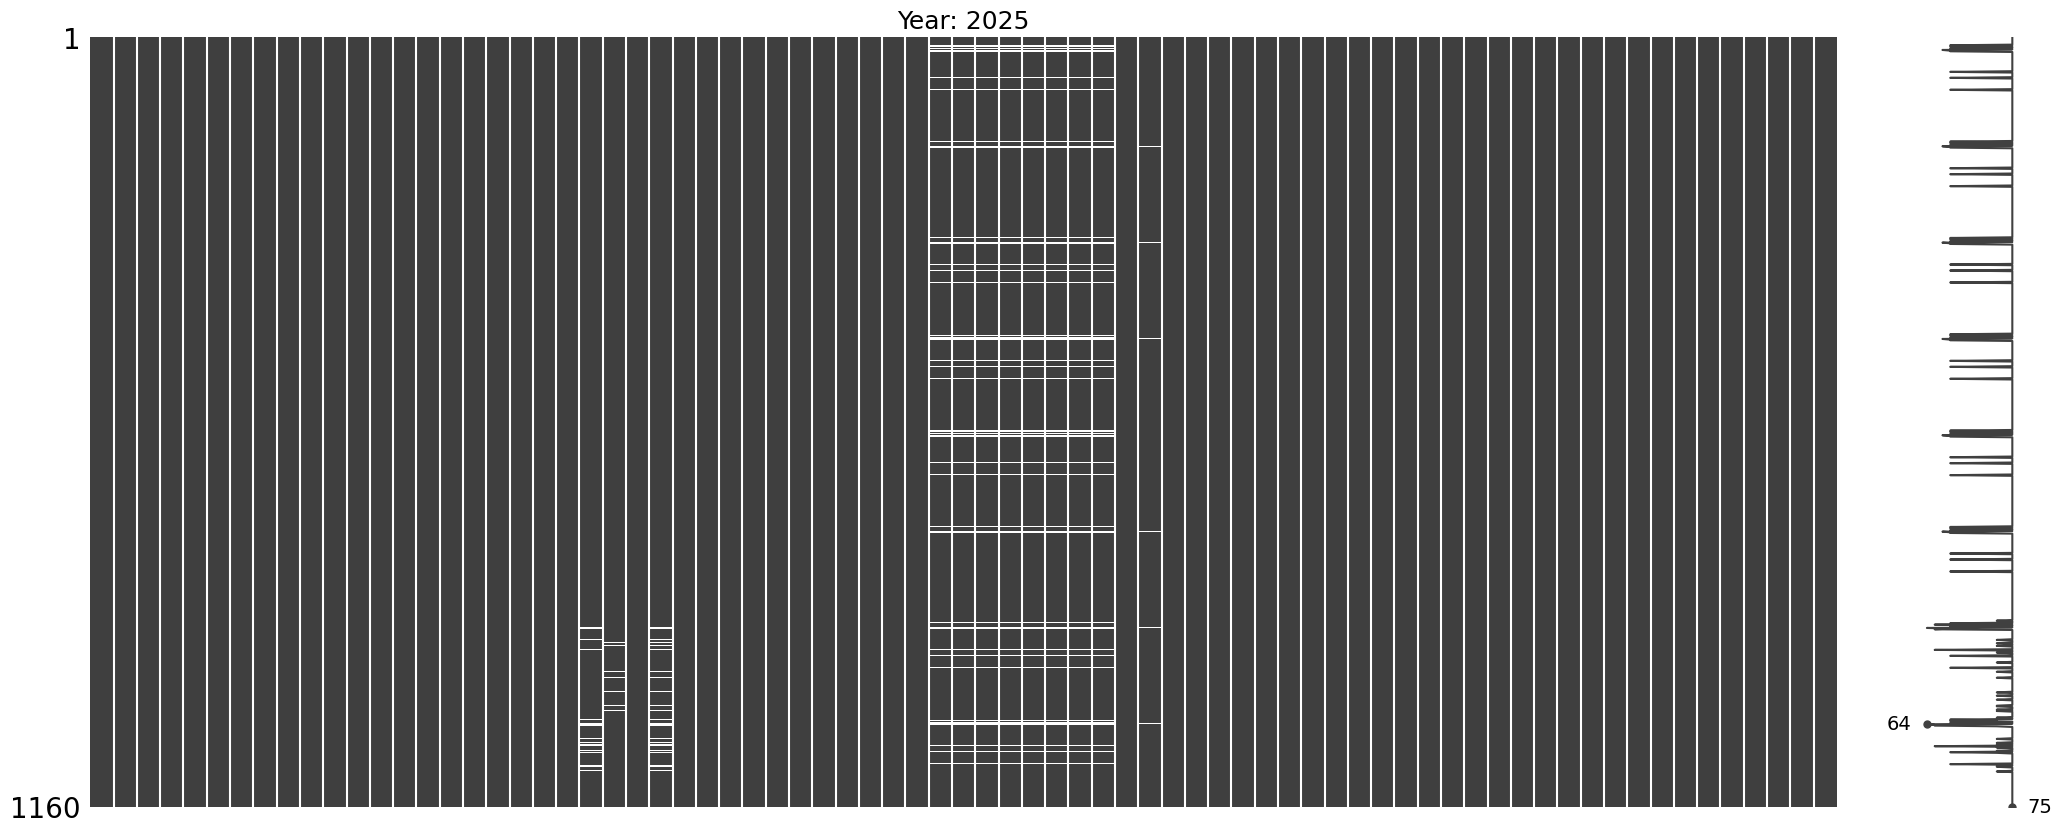

In [57]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [58]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,year_lc,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2025-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2025,1,0.221611,-0.115693,-0.351430,0.115693,0.222415,-0.121217,-0.359687,0.121217,0.014312,0.018195,0.016413,0.018195,33.593226,18.475655,0.019226,25.923931,0.500,0.866,11525.501547,1189.566737,3.200000,176.556138,234.750015,181.293075,0.0,4.122890,2024,2812.420746,750.981640,1.788854,48.896611,24.034117,1.205482,0.0,5.969408,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.514000,37.874000,0.596000,0.596000,29.1875,19.125,57.954545,304.651440,48.0,15.0,33.0,27.666667,29.833333,32.000000,26.833333,563.0,193.0,0.0,116.521944,507.0,13.0,43.0,199.0
1,2025-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2025,1,0.228015,-0.128318,-0.343611,0.128318,0.225038,-0.131594,-0.342374,0.131594,0.018079,0.017870,0.020000,0.017870,33.475393,19.666408,0.030405,26.519307,0.500,0.866,27643.505181,1357.065997,2.871795,173.781355,293.252756,180.811286,0.0,92.996499,2024,6064.190727,931.673366,1.641236,38.303046,43.861207,1.301525,0.0,459.006647,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.601795,37.660769,0.942564,0.942564,29.8125,18.375,55.681818,322.863859,49.0,16.0,33.0,27.666667,30.500000,33.166667,27.000000,593.0,210.0,0.0,123.588908,553.0,13.0,34.0,360.0
2,2025-01,nord,benoue,bibemi,bide,13.972945,9.422292,2025,1,0.228220,-0.101896,-0.347788,0.101896,0.231374,-0.096971,-0.352921,0.096971,0.015842,0.016957,0.016130,0.016957,33.477699,19.521544,0.014194,26.467861,0.500,0.866,22660.822965,1318.020573,2.600000,168.650613,304.317929,180.301336,0.0,93.489080,2024,5555.845612,719.271733,1.242118,31.219410,20.072188,1.639950,0.0,330.447001,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,16.912667,37.439333,0.440000,0.440000,30.0000,19.500,55.714286,401.781746,51.0,16.0,35.0,27.166667,30.500000,34.166667,26.666667,521.0,169.0,0.0,119.224151,478.0,4.0,42.0,164.0
3,2025-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2025,1,0.248493,-0.103664,-0.337475,0.103664,0.249743,-0.108167,-0.342317,0.108167,0.020745,0.028386,0.021056,0.028386,32.457507,18.103358,0.002199,25.280433,0.500,0.866,6789.434645,1430.318925,2.181818,167.127816,200.161964,180.523037,0.0,5.106007,2024,4263.616083,736.589253,1.167748,24.830296,14.391049,1.040369,0.0,7.221327,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,15.577273,36.582727,0.068182,0.068182,28.6875,18.125,58.467742,287.771611,46.0,15.0,31.0,27.500000,28.833333,31.333333,26.166667,551.0,203.0,0.0,119.238212,501.0,15.0,45.0,208.0
4,2025-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2025,1,0.215481,-0.051379,-0.305649,0.051379,0.217226,-0.045809,-0.312697,0.045809,0.023719,0.023485,0.028914,0.023485,32.857527,21.004111,0.000000,26.898167,0.500,0.866,5443.506799,2018.690644,9.333333,194.838800,332.209587,175.000090,0.0,6.187549,2024,4805.139710,451.444712,9.712535,47.638218,77.268242,7.151423,0.0,7.464223,31.0,36.0,30.0,12.0,12.0,3.0,5.0,8.0,18.743333,38.456667,0.000000,0.000000,30.6250,18.000,62.068966,274.837614,47.0,18.0,29.0,28.833333,30.333333,33.666667,28.166667,595.0,199.0,0.0,120.248526,546.0,3.0,48.0,200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [59]:
dataset[dataset.select_dtypes(include='float').columns] = dataset.select_dtypes(include='float').round(6)

rainfall_cols = [col for col in dataset.columns if 'rainfall' in col]
dataset[rainfall_cols] = dataset[rainfall_cols].round(4)

lst_cols = [col for col in dataset.columns if 'lst' in col]
dataset[lst_cols] = dataset[lst_cols].round(2)

bio_cols = [col for col in dataset.columns if 'bio' in col]
dataset[bio_cols] = dataset[bio_cols].round(2)

geo_cols += [f"{col}_std" for col in geo_cols]
dataset[geo_cols] = dataset[geo_cols].round(2)

dataset[mode_cols] = dataset[mode_cols].apply(pd.to_numeric, errors='coerce').astype('Int64')



In [60]:
dataset.shape

(1160, 75)

In [61]:
new_order = ['dt_placement',
             'year',
             'month',
             'year_lc',
             'month_sin',
             'month_cos',
             'GID0',
             'GID1',
             'GID2',
             'GID3',
             'x',
             'y',
             'ndvi',
             'ndmi',
             'ndwi',
             'ndbi',
             'ndvi_mean',
             'ndmi_mean',
             'ndwi_mean',
             'ndbi_mean',
             'ndvi_std',
             'ndmi_std',
             'ndwi_std',
             'ndbi_std',
             'lst',
             'lst_day',
             'lst_night',
             'monthly_lst_min',
             'monthly_lst_max',
             'rainfall',
             'rainfall_acc',
             'monthly_rainfall_acc',
             'distance_to_coast', 
             'distance_to_river', 
             'slope_mean_1km',
             'aspect_mean_200m', 
             'elevation_mean_1km', 
             'hillshade_mean_1km',
             'fs_area_1km', 
             'flow_accu_200m', 
             'distance_to_coast_std',
             'distance_to_river_std', 
             'slope_mean_1km_std', 
             'aspect_mean_200m_std',
             'elevation_mean_1km_std', 
             'hillshade_mean_1km_std', 
             'fs_area_1km_std',
             'flow_accu_200m_std', 
             'lc_prop1', 
             'lc_prop2', 
             'lc_prop3', 
             'lc_type1',
             'lc_type2', 
             'lc_type3', 
             'lc_type4', 
             'lc_type5',
             'bio1',
             'bio2',
             'bio3',
             'bio4',
             'bio5',
             'bio6',
             'bio7',
             'bio8',
             'bio9',
             'bio10',
             'bio11',
             'bio12',
             'bio13',
             'bio14',
             'bio15',
             'bio16',
             'bio17',
             'bio18',
             'bio19']

In [62]:
dataset = dataset[new_order]

In [63]:
dataset.head()

,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.221611,-0.115693,-0.351430,0.115693,0.222415,-0.121217,-0.359687,0.121217,0.014312,0.018195,0.016413,0.018195,25.92,33.59,18.48,15.51,37.87,0.0192,0.5960,0.5960,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36,30,12,12,3,5,8,29.19,19.12,57.95,304.65,48.0,15.0,33.0,27.67,29.83,32.00,26.83,563.0,193.0,0.0,116.52,507.0,13.0,43.0,199.0
1,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.228015,-0.128318,-0.343611,0.128318,0.225038,-0.131594,-0.342374,0.131594,0.018079,0.017870,0.020000,0.017870,26.52,33.48,19.67,16.60,37.66,0.0304,0.9426,0.9426,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36,30,12,12,3,5,8,29.81,18.38,55.68,322.86,49.0,16.0,33.0,27.67,30.50,33.17,27.00,593.0,210.0,0.0,123.59,553.0,13.0,34.0,360.0
2,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.228220,-0.101896,-0.347788,0.101896,0.231374,-0.096971,-0.352921,0.096971,0.015842,0.016957,0.016130,0.016957,26.47,33.48,19.52,16.91,37.44,0.0142,0.4400,0.4400,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36,30,12,12,3,5,8,30.00,19.50,55.71,401.78,51.0,16.0,35.0,27.17,30.50,34.17,26.67,521.0,169.0,0.0,119.22,478.0,4.0,42.0,164.0
3,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.248493,-0.103664,-0.337475,0.103664,0.249743,-0.108167,-0.342317,0.108167,0.020745,0.028386,0.021056,0.028386,25.28,32.46,18.10,15.58,36.58,0.0022,0.0682,0.0682,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36,30,12,12,3,5,8,28.69,18.12,58.47,287.77,46.0,15.0,31.0,27.50,28.83,31.33,26.17,551.0,203.0,0.0,119.24,501.0,15.0,45.0,208.0
4,2025-01,2025,1,2024,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215481,-0.051379,-0.305649,0.051379,0.217226,-0.045809,-0.312697,0.045809,0.023719,0.023485,0.028914,0.023485,26.90,32.86,21.00,18.74,38.46,0.0000,0.0000,0.0000,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36,30,12,12,3,5,8,30.62,18.00,62.07,274.84,47.0,18.0,29.0,28.83,30.33,33.67,28.17,595.0,199.0,0.0,120.25,546.0,3.0,48.0,200.0


In [64]:
dataset.shape

(1160, 75)

In [65]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1160 entries, 0 to 1159
Data columns (total 75 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            1160 non-null   period[M]
 1   year                    1160 non-null   int32    
 2   month                   1160 non-null   int32    
 3   year_lc                 1160 non-null   int32    
 4   month_sin               1160 non-null   float64  
 5   month_cos               1160 non-null   float64  
 6   GID0                    1160 non-null   object   
 7   GID1                    1160 non-null   object   
 8   GID2                    1160 non-null   object   
 9   GID3                    1160 non-null   object   
 10  x                       1160 non-null   float64  
 11  y                       1160 non-null   float64  
 12  ndvi                    1160 non-null   float64  
 13  ndmi                    1160 non-null   float64  
 14  ndwi    

In [ ]:
# dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_grouped.csv', index=False, encoding=enc)

In [66]:
dataset.to_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_08_grouped.csv', index=False, encoding=enc)